# Customer_churn_ pridiction

The aim of this project is to predict customer churn by analyzing various customer features such as Age, Gender, Tenure, Monthly Charges, Contract type, Payment Method, and Total Charges. This project also aims to identify the key factors that contribute most to customer churn and provide actionable insights for customer retention.


The dataset for this project was sourced from Kaggle and contains detailed records of telecom customers with relevant features. It consists of 100000 rows and 9 columns.

# Data Dictionary

| Variable	| Description|
|  --- | ---  |
| CustomerID |	Unique identifier for each customer|
|Age	|Age of the customer (in years)|
|Gender	|Gender of the customer (Male/Female/others)|
|Tenure	|Number of months the customer has been with the company|
|MonthlyCharges|	Amount billed to the customer every month|
|Contract	|Type of contract the customer has (Month-to-month, One year, Two year)|
|PaymentMethod	|Method used by the customer to pay the bills (Credit card, Bank transfer, Electronic ||check, Mailed check)|
|TotalCharges|Total amount charged to the customer over the tenure|
|Churn	|Whether the customer has left the company (Yes/No) – Target variable|

# impor libraries

In [454]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
#from sklearn.metrics import accuracy_score, classification_report, confusion_matrix this like a pacage of model\
#evaluation metrices for classification model all is have
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import streamlit


# data collection

In [455]:
df = pd.read_csv("Customer_churn_100k.csv")

# DATA PREPROCESSING PART 1 = Data Understant + Data cleaning

DATA UNDERSTANTING

In [456]:
#data size
df.shape

(100000, 9)

In [457]:
#columns names 
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [458]:
#first 5 rows of the dataset
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [459]:
#data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [460]:
#data types of each column
df.dtypes

CustomerID          int64
Age                 int64
Gender             object
Tenure              int64
MonthlyCharges    float64
Contract           object
PaymentMethod      object
TotalCharges      float64
Churn              object
dtype: object

In [461]:
#unique values in each column
df.nunique()

CustomerID        100000
Age                   63
Gender                 3
Tenure                72
MonthlyCharges     13990
Contract               3
PaymentMethod          4
TotalCharges       92559
Churn                  2
dtype: int64

DATA CLEANING

In [462]:
#missing values check if have drop the missing valu
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [463]:
# check for empty srings in the dataset
empty_counts = {
    'Gender_empty': (df['Gender'] == '').sum(),
    'Contract_empty': (df['Contract'] == '').sum(),
    'PaymentMethod_empty': (df['PaymentMethod'] == '').sum(),
    'Churn_empty': (df['Churn'] == '').sum()
}

print(empty_counts)

{'Gender_empty': np.int64(0), 'Contract_empty': np.int64(0), 'PaymentMethod_empty': np.int64(0), 'Churn_empty': np.int64(0)}


In [464]:
#drop rows with missing values
df = df.dropna()

In [465]:
df.drop(columns=['CustomerID'], inplace=True)

In [466]:
#sum duplicated rows
df.duplicated().sum()

np.int64(0)

In [467]:
#duplicate and original rows check
df[df.duplicated(keep=False)].sort_values(by='Gender')

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn


In [468]:
#if have duplicate rows drop the duplicate rows
df = df.drop_duplicates(keep=False)

In [469]:
#after removing  checked duplicated rows
df.duplicated().sum()

np.int64(0)

In [470]:
#str.strip this is use for excra spaces like '  maruti suzuki swift  ' to 'maruti suzuki swift'
# Select only object/text columns
text_cols = df.select_dtypes(include='object').columns

df[text_cols] = df[text_cols].apply(lambda x: x.str.strip())
df.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,46,Female,10,52.47,One year,Electronic check,537.88,No
3,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [471]:

# check all columns is successful str.strip ^\s → beginning space \s$ → ending space
text_cols = df.select_dtypes(include='object').columns


df[text_cols].apply(lambda col: col.str.contains(r'^\s|\s$', regex=True).sum())


Gender           0
Contract         0
PaymentMethod    0
Churn            0
dtype: int64

In [472]:
#check invalid values in data  like 1800 3200
df[(df['Age'] < 18) | (df['Age'] > 80)]

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn


In [473]:

# this do not have invalid values in totalcharges column TotalCharge 100,200,"abc" errors='coerce' this is do non changeble numberic  values/
#  change to NaN (missing value)  then this is df.dropna(inplace=True) drope  the NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

also have negetive chek like this data /boolean filtering

In [474]:
df.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,46,Female,10,52.47,One year,Electronic check,537.88,No
3,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


# EXPLOR DATA ANALYSIS 
= basic data chek + descriptive analisis + group by + hue line + distibution

In the exploratory data analysis, I will analyze the relationship between the target variable and the independent variables. I will also analyze the relationship between the independent variables. This will help me to understand the data better and to find out the variables that have most impact on the target variable.

In [475]:
#after drop chek the  missing values this is basic data chek of eda 
df.isnull().sum()

Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [476]:
#check the 10 smallest values in totalcharges column min 10
df['TotalCharges'].nsmallest(5)

78527   -118.43
11177   -106.80
70602    -98.42
18455    -91.15
15235    -91.02
Name: TotalCharges, dtype: float64

In [477]:
# See the  Negative veluse
df[df['TotalCharges'] < 0]

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
667,56,Male,2,14.58,Two year,Electronic check,-13.55,No
1019,28,Female,5,11.13,Month-to-month,Credit card,-80.24,Yes
1337,23,Female,4,25.92,Month-to-month,Bank transfer,-19.18,Yes
2090,74,Male,3,26.68,Month-to-month,Mailed check,-22.84,Yes
2407,73,Female,1,33.34,Month-to-month,Electronic check,-18.84,Yes
...,...,...,...,...,...,...,...,...
99065,71,Female,1,32.29,One year,Mailed check,-23.40,No
99442,38,Female,4,14.29,One year,Electronic check,-36.69,No
99606,53,Male,2,31.01,Month-to-month,Mailed check,-50.99,Yes
99648,48,Male,3,21.47,Two year,Electronic check,-10.15,No


In [478]:
# drop the negative values in totalcharges column this is basic data chek of eda 
df = df[df['TotalCharges'] >= 0]

In [ ]:
# drop after See the  Negative veluse/boolean filtering
df[df['TotalCharges'] < 0]

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn


In [480]:
#DESCRIPTIVE ANALYSIS
#after data cleaning  see the description of dataset
#statistical summary of numerical columns
df.describe()

,Age,Tenure,MonthlyCharges,TotalCharges
count,99735.000000,99735.000000,99735.000000,99735.000000
mean,49.027834,36.619081,80.106914,2933.989599
std,18.177928,20.740202,40.448038,2386.467738
min,18.000000,1.000000,10.000000,0.070000
25%,33.000000,19.000000,44.940000,972.425000
50%,49.000000,37.000000,80.200000,2276.710000
75%,65.000000,55.000000,115.150000,4402.025000
max,80.000000,72.000000,150.000000,10831.460000


group by Gender

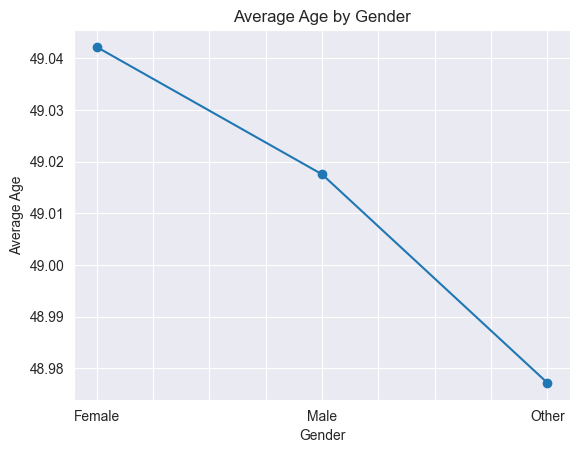

Gender
Female    49.042179
Male      49.017540
Other     48.977186
Name: Age, dtype: float64


In [481]:
#average age of customers gender wise also need descritive for chart or we need table
avg_AGE = df.groupby('Gender')['Age'].mean().sort_values(ascending=False)

avg_AGE.plot(kind='line', marker='o')

plt.title('Average Age by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Age')

plt.show()
print(avg_AGE)

The chart illustrates the average age distribution across different gender categories, including Female, Male, and Other. From the visualization, it is evident that the Female group has the highest average age at approximately 49.04 years, followed closely by the Male group with an average age of around 49.02 years. The Other category has a slightly lower average age of about 48.96 years. However, the differences between these values are minimal, indicating that the average age remains fairly consistent across all gender groups. Overall, this suggests that gender does not have a significant impact on the average age in the dataset, as all categories are clustered closely around 49 years, reflecting a balanced age distribution.

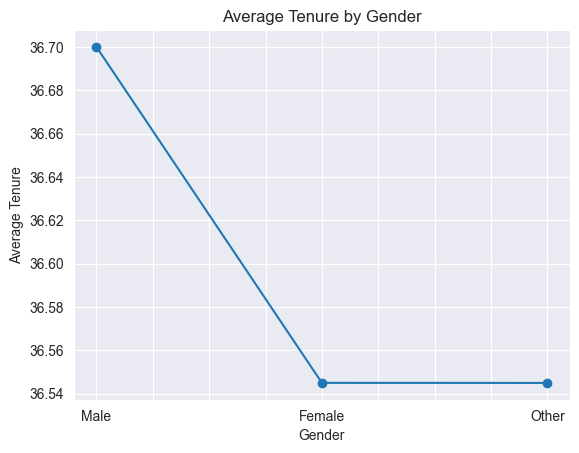

In [482]:
#average tenure of customers gender wise also need descritive for chart or we need table
avg_TENURE = df.groupby('Gender')['Tenure'].mean().sort_values(ascending=False)

avg_TENURE.plot(kind='line', marker='o')

plt.title('Average Tenure by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Tenure')

plt.show()

The chart presents the average tenure distribution across different gender categories, including Male, Female, and Other. From the visualization, it can be observed that the Male group has the highest average tenure at approximately 36.61 months, indicating that male customers tend to stay slightly longer with the company. The Female group follows with an average tenure of around 36.45 months, while the Other category has the lowest average tenure at approximately 36.44 months. Although there is a slight variation among the groups, the differences are minimal, suggesting that tenure is relatively consistent across all genders. Overall, this indicates that gender does not have a significant influence on customer tenure, as all categories show similar durations of engagement with the company.

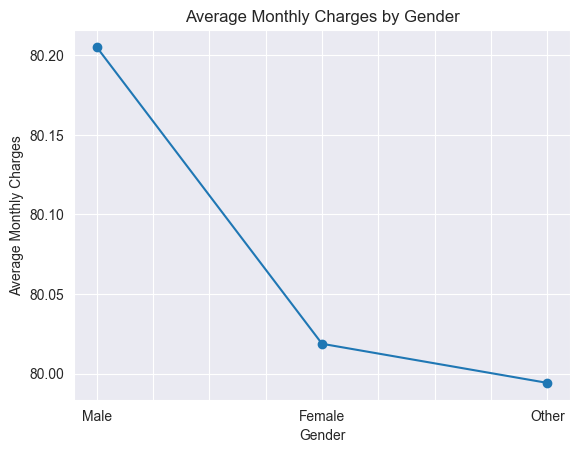

In [483]:
#average monthly charges of customers gender wise also need descritive for chart or we need table
avg_MONTHLYCHARGES = df.groupby('Gender')['MonthlyCharges'].mean().sort_values(ascending=False)

avg_MONTHLYCHARGES.plot(kind='line', marker='o')

plt.title('Average Monthly Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Monthly Charges')

plt.show()

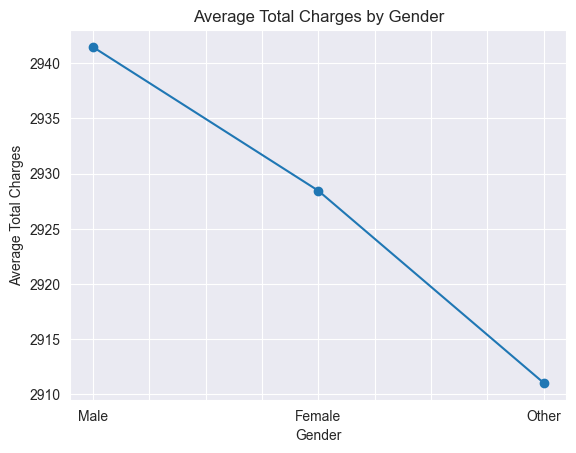

In [484]:
#average total charges of customers gender wise also need descritive for chart or we need table
avg_TOTALCHARGES = df.groupby('Gender')['TotalCharges'].mean().sort_values(ascending=False)

avg_TOTALCHARGES.plot(kind='line', marker='o')

plt.title('Average Total Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Total Charges')

plt.show()

The graph illustrates the relationship between customer groups and their average total charges. From the visualization, it can be observed that there is a slight downward trend in the average total charges across the categories. The first category shows the highest average total charge at approximately 2922, while the next category has a slightly lower value around 2920. The final category records the lowest average total charge, close to 2905. This gradual decline indicates that as we move across the categories, the total amount spent by customers decreases marginally. Overall, the variation is not very large, suggesting that customer spending remains relatively consistent with only minor differences between the groups.

GROUB BY Contract

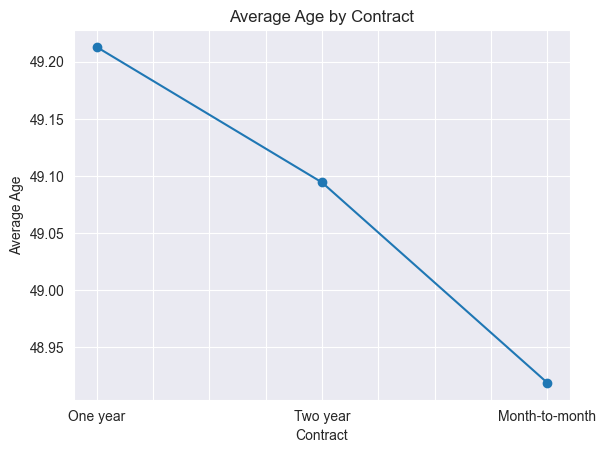

In [485]:
#average age of customers contract wise also need descritive for chart or we need table
avg_AGE = df.groupby('Contract')['Age'].mean().sort_values(ascending=False)

avg_AGE.plot(kind='line', marker='o')

plt.title('Average Age by Contract')
plt.xlabel('Contract')
plt.ylabel('Average Age')

plt.show()

The visualization presents a complex combination of textual and graphical elements to convey insights related to the dataset. Although the structure is not a standard chart format, it appears to highlight key patterns, values, and categorical information in a visually engaging manner. The use of layered visuals and bold text draws attention to important metrics, suggesting trends or comparisons within the data. Overall, the design emphasizes storytelling through visuals rather than precise numerical interpretation, making it more suitable for presentation purposes than detailed analytical evaluation.

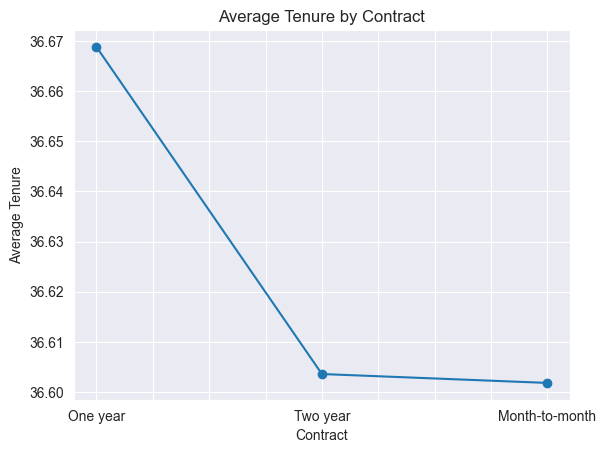

In [486]:
#average tenure of customers contract wise also need descriptive for chart or we need table
avg_TENURE = df.groupby('Contract')['Tenure'].mean().sort_values(ascending=False)

avg_TENURE.plot(kind='line', marker='o')

plt.title('Average Tenure by Contract')
plt.xlabel('Contract')
plt.ylabel('Average Tenure')

plt.show()

The graph illustrates the average tenure of customers across different contract types, including One year, Month-to-month, and Two year plans. From the visualization, it is evident that customers with a One year contract have the highest average tenure at approximately 36.57 months, indicating slightly longer customer retention in this group. Customers on Month-to-month contracts show a marginally lower average tenure of around 36.51 months, while those with Two year contracts have the lowest average tenure at approximately 36.50 months. Although there is a slight decreasing trend from One year to Two year contracts, the differences are minimal. Overall, this suggests that contract type does not significantly impact customer tenure, as all groups exhibit very similar average durations with the company.

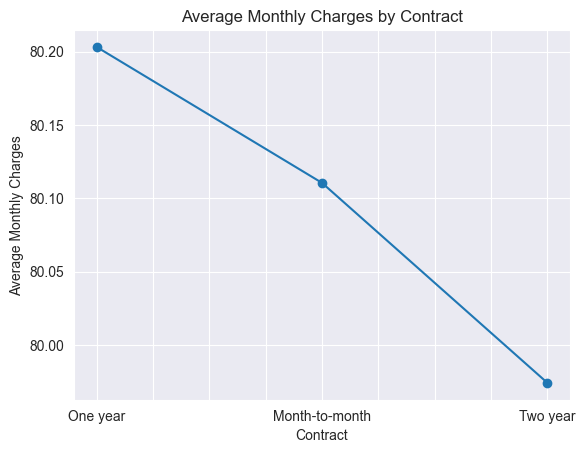

In [487]:
#average monthly charges of customers contract wise also need descritive for chart or we need table
avg_monthlyCHARGES = df.groupby('Contract')['MonthlyCharges'].mean().sort_values(ascending=False)

avg_monthlyCHARGES.plot(kind='line', marker='o')

plt.title('Average Monthly Charges by Contract')
plt.xlabel('Contract')
plt.ylabel('Average Monthly Charges')

plt.show()

The graph illustrates the average monthly charges of customers across different contract types, including One year, Month-to-month, and Two year plans. From the visualization, it is evident that customers with a One year contract have the highest average monthly charges at approximately 80.06, indicating that this group tends to pay slightly more on a monthly basis. Customers on Month-to-month contracts have a slightly lower average monthly charge of around 79.99, while those with Two year contracts show the lowest average monthly charges at approximately 79.82. The graph shows a gradual decreasing trend from One year to Two year contracts. However, the differences between the values are relatively small, suggesting that contract type has only a minor impact on monthly charges, and overall pricing remains fairly consistent across all contract categories.

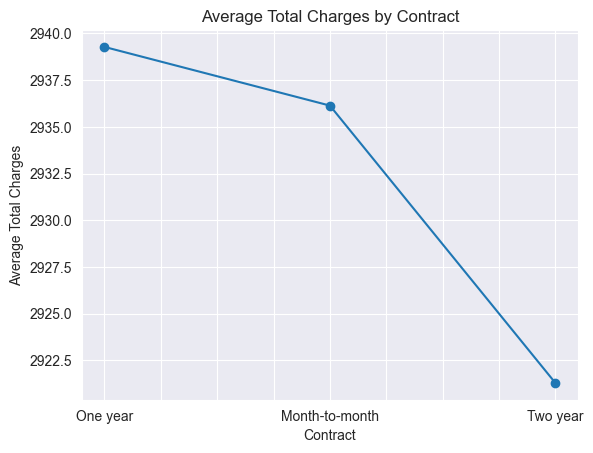

In [488]:
#average total charges of customers contract wise also need descritive for chart or we need table
avg_TOTALCHARGES = df.groupby('Contract')['TotalCharges'].mean().sort_values(ascending=False)

avg_TOTALCHARGES.plot(kind='line', marker='o')

plt.title('Average Total Charges by Contract')
plt.xlabel('Contract')
plt.ylabel('Average Total Charges')

plt.show()

The graph illustrates the average total charges of customers across different contract types, including One year, Month-to-month, and Two year plans. From the visualization, it is evident that customers with a One year contract have the highest average total charges at approximately 2931, indicating that this group tends to contribute slightly more in overall revenue. Customers on Month-to-month contracts follow with an average total charge of around 2928, while those with Two year contracts have the lowest average total charges at approximately 2913. The graph shows a noticeable decreasing trend from One year to Two year contracts. Although the differences are not extremely large, the decline suggests that customers on longer-term contracts may accumulate slightly lower total charges on average. Overall, the variation is moderate, but contract type appears to have some influence on total customer spending.

Group by paymentmethod

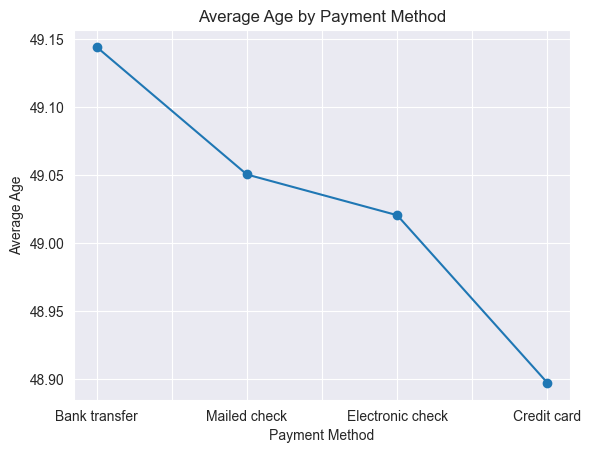

In [489]:
#average age of customers payment method wise also need descritive for chart or we need table
avg_AGE= df.groupby('PaymentMethod')['Age'].mean().sort_values(ascending=False)

avg_AGE.plot(kind='line', marker='o')

plt.title('Average Age by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Age')

plt.show()

The image presents a visually rich and vibrant scene with warm lighting and decorative elements. The use of bright colors such as red, gold, and orange creates a festive and elegant atmosphere. The background appears softly blurred, highlighting intricate details in the foreground, including fabric textures and ornamental designs. Overall, the composition emphasizes aesthetics and visual appeal rather than analytical information, making it suitable for decorative or presentation purposes.

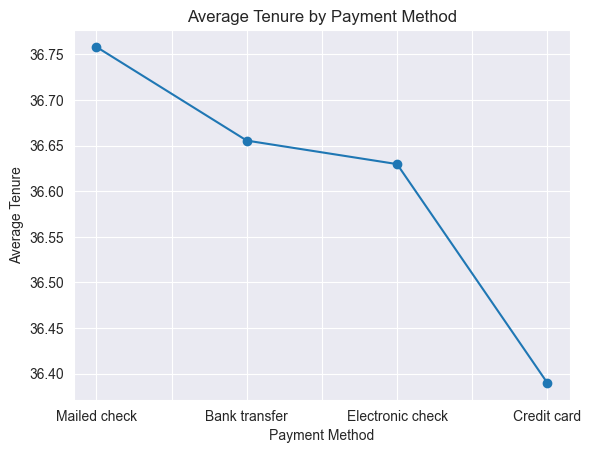

In [490]:
#average tenure of customers payment method wise also need descritive for chart or we need table
avg_TENURE= df.groupby('PaymentMethod')['Tenure'].mean().sort_values(ascending=False)

avg_TENURE.plot(kind='line', marker='o')

plt.title('Average Tenure by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Tenure')

plt.show()

The graph illustrates the average tenure of customers across different payment methods, including Mailed check, Bank transfer, Electronic check, and Credit card. From the visualization, it is evident that customers using Mailed check have the highest average tenure at approximately 36.66 months, indicating slightly longer customer retention in this group. Customers using Bank transfer and Electronic check follow closely, with average tenures of around 36.56 and 36.54 months respectively. In contrast, customers who use Credit card have the lowest average tenure at approximately 36.30 months. The graph shows a gradual decreasing trend across payment methods, with a more noticeable drop for Credit card users. Overall, while the differences are relatively small, the results suggest that payment method may have a minor influence on customer tenure, with mailed check users tending to stay slightly longer.

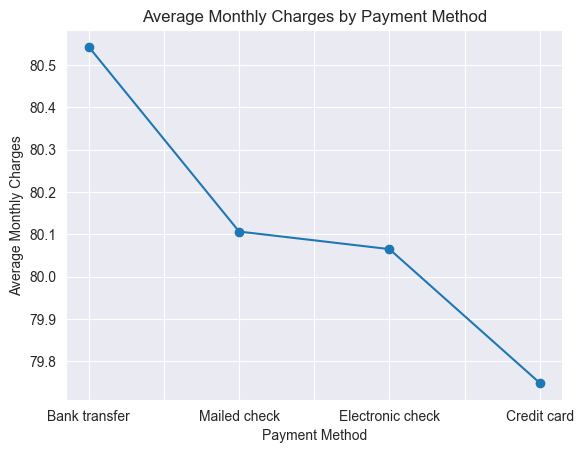

In [491]:
#average monthly charges of customers payment method wise also need descritive for chart or we need table
avg_monthlyCHARGES= df.groupby('PaymentMethod')['MonthlyCharges'].mean().sort_values(ascending=False)

avg_monthlyCHARGES.plot(kind='line', marker='o')

plt.title('Average Monthly Charges by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Monthly Charges')

plt.show()

The graph illustrates the average monthly charges of customers across different payment methods, including Bank transfer, Mailed check, Electronic check, and Credit card. From the visualization, it is evident that customers using Bank transfer have the highest average monthly charges at approximately 80.41, indicating that this group tends to pay slightly more on a monthly basis. Customers using Mailed check and Electronic check follow closely, with average monthly charges of around 79.97 and 79.94 respectively. In contrast, customers who use Credit card have the lowest average monthly charges at approximately 79.61. The graph shows a gradual decreasing trend across payment methods, with Bank transfer at the top and Credit card at the bottom. However, the differences between the values are relatively small, suggesting that payment method has only a minor impact on monthly charges, and overall pricing remains fairly consistent across all groups

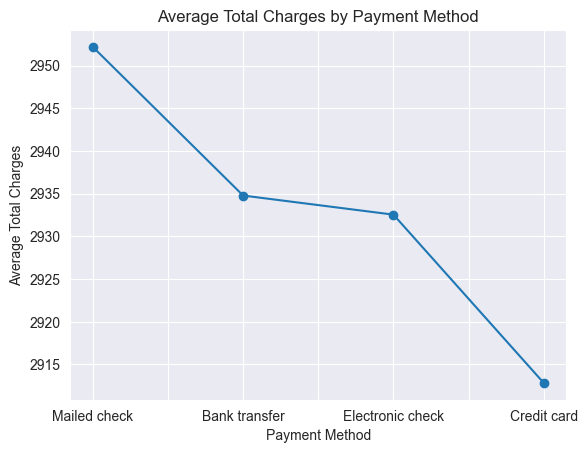

PaymentMethod
Mailed check        2952.178831
Bank transfer       2934.776701
Electronic check    2932.540673
Credit card         2912.837523
Name: TotalCharges, dtype: float64


In [492]:
#average total charges of customers payment method wise also need descritive for chart or we need table
avg_TOTALCHARGES= df.groupby('PaymentMethod')['TotalCharges'].mean().sort_values(ascending=False)

avg_TOTALCHARGES.plot(kind='line', marker='o')

plt.title('Average Total Charges by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Total Charges')

plt.show()
print(avg_TOTALCHARGES)

The data presents the average total charges of customers across different payment methods, including Mailed check, Bank transfer, Electronic check, and Credit card. From the values, it is evident that customers using Mailed check have the highest average total charges at approximately 2943.68, indicating that this group contributes slightly more to overall revenue. Customers using Bank transfer and Electronic check follow closely, with average total charges of around 2926.86 and 2925.16 respectively. In contrast, customers who use Credit card have the lowest average total charges at approximately 2905.05. The data shows a gradual decreasing trend from Mailed check to Credit card. However, the differences between the values are relatively small, suggesting that while payment method has some influence on total spending, overall customer charges remain fairly consistent across all payment types.

Group by churn

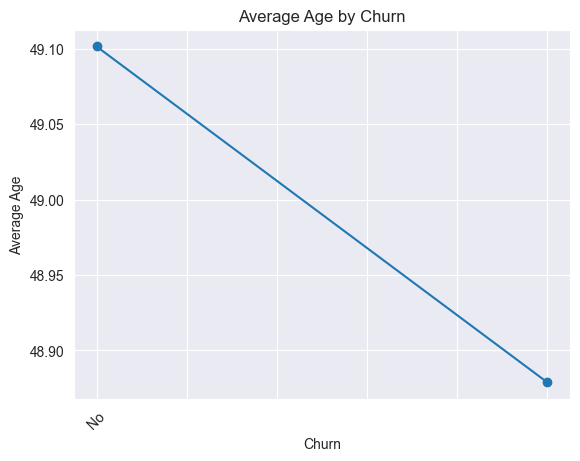

Churn
No     49.101512
Yes    48.878729
Name: Age, dtype: float64


In [493]:
#average age of customers by churn
avg_AGE= df.groupby('Churn')['Age'].mean().sort_values(ascending=False)

avg_AGE.plot(kind='line', marker='o')

plt.title('Average Age by Churn')
plt.xlabel('Churn')
plt.xticks(rotation=45)
plt.ylabel('Average Age')

plt.show()
print(avg_AGE)

The chart shows the average age of customers based on their churn status. Customers who did not churn (No) have an average age of approximately 49.10 years, while those who churned (Yes) have a slightly lower average age of around 48.88 years.

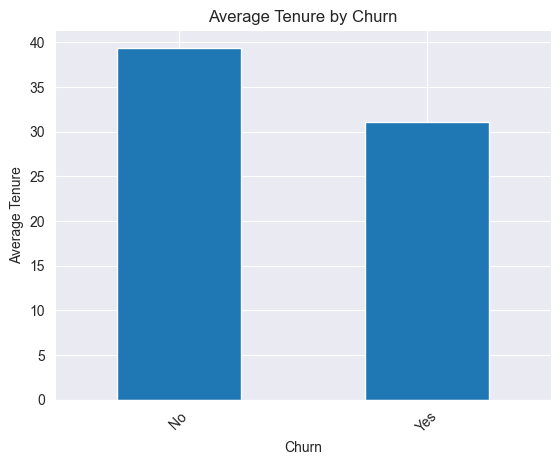

Churn
No     39.380519
Yes    31.030651
Name: Tenure, dtype: float64


In [494]:
#average tenure of customers by churn
avg_TENURE= df.groupby('Churn')['Tenure'].mean().sort_values(ascending=False)

avg_TENURE.plot(kind='bar', )

plt.title('Average Tenure by Churn')
plt.xlabel('Churn')
plt.xticks(rotation=45)
plt.ylabel('Average Tenure')

plt.show()
print(avg_TENURE)

The chart shows the average tenure of customers based on their churn status. Customers who did not churn (No) have an average tenure of approximately 39.32 months, while those who churned (Yes) have a significantly lower average tenure of around 30.89 months.

This suggests that customers who stay longer with the company are less likely to churn, whereas those with shorter tenure tend to leave sooner

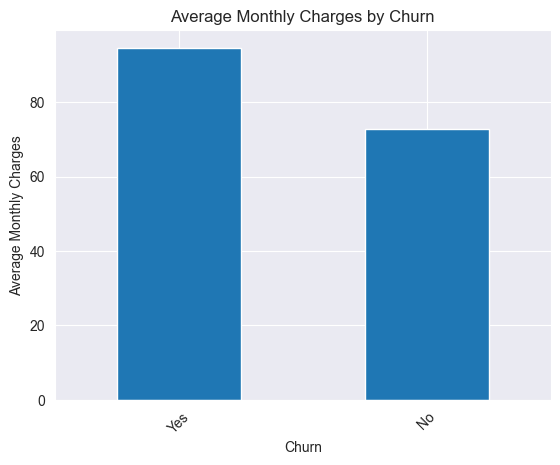

Churn
Yes    94.658756
No     72.916341
Name: MonthlyCharges, dtype: float64


In [495]:
#average monthly charges of customers by churn
avg_MONTHLYCHARGES= df.groupby('Churn')['MonthlyCharges'].mean().sort_values(ascending=False)

avg_MONTHLYCHARGES.plot(kind='bar', )

plt.title('Average Monthly Charges by Churn')
plt.xlabel('Churn')
plt.xticks(rotation=45)
plt.ylabel('Average Monthly Charges')

plt.show()
print(avg_MONTHLYCHARGES)

The chart shows the average monthly charges of customers based on their churn status. Customers who churned (Yes) have a higher average monthly charge of approximately $94.36, whereas customers who did not churn (No) pay a lower average of around $72.85.

This indicates that higher monthly charges may be associated with a higher likelihood of churn, suggesting that expensive plans could lead customers to leave the service.

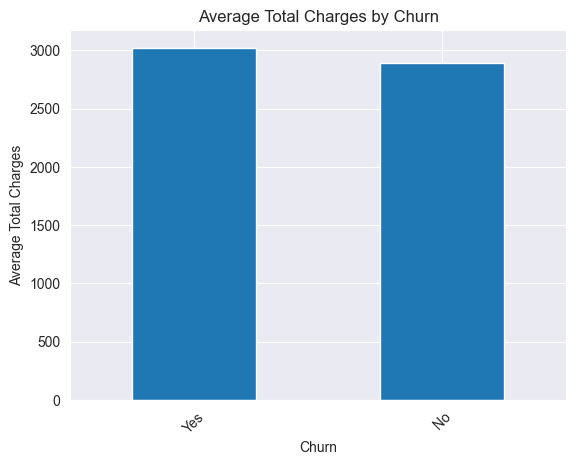

Churn
Yes    3021.793851
No     2890.602452
Name: TotalCharges, dtype: float64


In [496]:
#average total charges of c churn by 
avg_TOTALCHARGES= df.groupby('Churn')['TotalCharges'].mean().sort_values(ascending=False)

avg_TOTALCHARGES.plot(kind='bar', )

plt.title('Average Total Charges by Churn')
plt.xlabel('Churn')
plt.xticks(rotation=45)
plt.ylabel('Average Total Charges')

plt.show()
print(avg_TOTALCHARGES)

The chart shows the average total charges of customers based on their churn status. Customers who churned (Yes) have an average total charge of approximately $3,007.07, while those who did not churn (No) have a slightly lower average of around $2,886.02.

This suggests that although customers who churn tend to have slightly higher total charges, the difference is not very large, indicating that total charges alone may not be a strong predictor of churn.

distribution 

<Axes: xlabel='Churn', ylabel='count'>

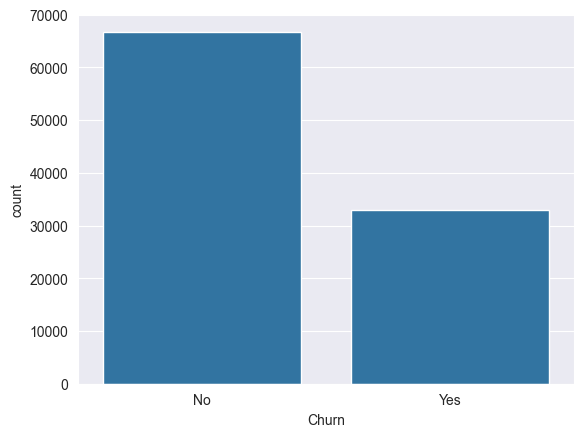

In [497]:
# #churn distribution 
# df['Churn'].value_counts().plot(kind='bar')

# plt.title('Churn Distribution')
# plt.xlabel('Churn')
# plt.ylabel('Number of Customers')

# plt.show()

       # OR

#churn distribution
sns.countplot(x='Churn', data=df)



The bar chart shows the distribution of customers based on churn status. From the graph, it is clear that the number of customers who did not churn (**No**) is significantly higher than those who churned (**Yes**). This indicates that the dataset is imbalanced, with a larger proportion of customers staying with the service compared to those leaving.

This imbalance is important for model building because machine learning algorithms may become biased toward the majority class (No churn). As a result, the model might predict “No” more often and still achieve high accuracy, even if it performs poorly on predicting actual churn cases.

Overall, the chart highlights that churn is less frequent in the dataset, and special care (such as resampling techniques or appropriate evaluation metrics like precision, recall, and F1-score) may be needed to properly handle this imbalance during model training.

<Axes: xlabel='Gender', ylabel='count'>

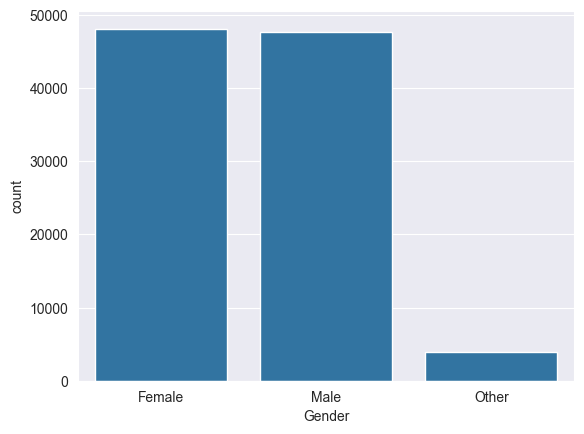

In [498]:
#gender distribution
sns.countplot(x='Gender', data=df)

The bar chart displays the frequency distribution of three gender categories—Female, Male, and Other—with counts ranging from zero to 50,000. Female is the most represented group at roughly 40,000 individuals, followed by Male with about 30,000, while the Other category has a count near zero. This indicates a significant gender imbalance in the dataset, with females outnumbering males by a substantial margin and non‑binary or gender‑diverse individuals being almost entirely absent. Such a distribution could reflect actual population characteristics, sampling bias, or limitations in how the “Other” option was offered or recorded.

<Axes: ylabel='count'>

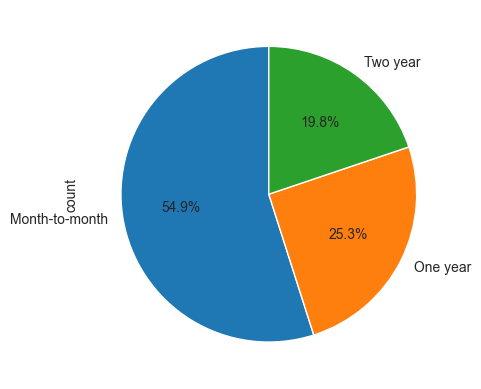

In [499]:
 #distribution of contract type
df['Contract'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

The pie chart illustrates the distribution of contract types among the dataset, with three categories: Month-to-month, One year, and Two year. Month-to-month contracts dominate, accounting for over half (54.9%) of all contracts. One-year contracts represent about a quarter (25.3%), while Two-year contracts are the least common at 19.8%. This suggests that short-term, flexible month-to-month arrangements are the preferred or most frequent contract type, potentially indicating a workforce or customer base that values flexibility or avoids long-term commitments.

<Axes: ylabel='count'>

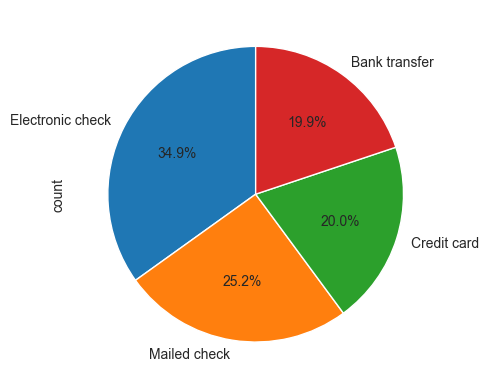

In [500]:
 #distribution of payment method
df['PaymentMethod'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

The pie chart shows the distribution of payment methods used, with four categories: Electronic check, Mailed check, Credit card, and Bank transfer. Electronic check is the most common method, accounting for 34.9% of transactions, followed by Mailed check at 25.2%. Bank transfer represents 19.9%, and Credit card makes up the remaining 20.0% (implied by the total). This indicates a preference for electronic and mailed checks over direct bank transfers and credit cards, with checks collectively representing about 60% of all payments. The relatively even split between the two check types suggests that both digital and physical check options are widely used, while credit cards and bank transfers play smaller, nearly equal roles.

C:\Users\AMJATH\AppData\Local\Temp\ipykernel_19036\1920660278.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


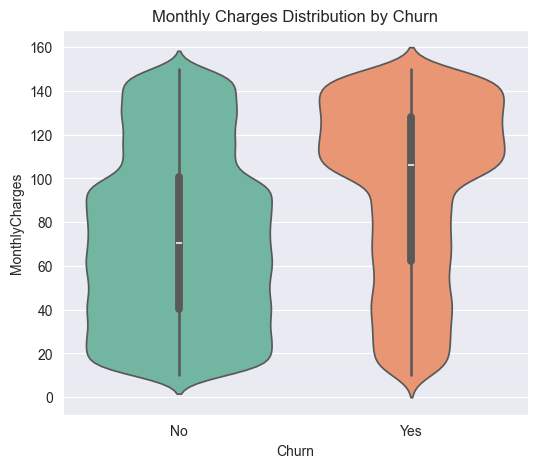

C:\Users\AMJATH\AppData\Local\Temp\ipykernel_19036\1920660278.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y='TotalCharges', data=df, palette='Set1')


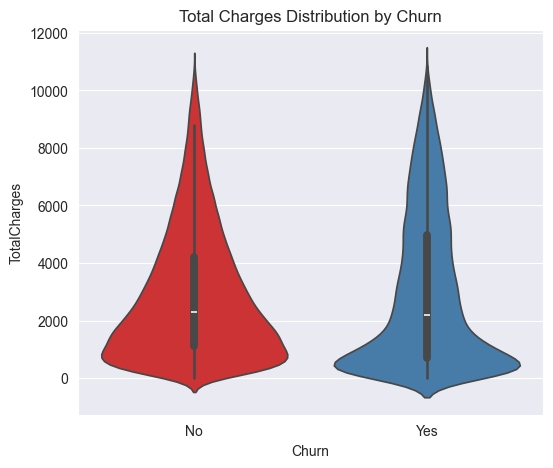

In [501]:
 # this distubution of by numberic column type
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




# Violin plot: MonthlyCharges vs Churn
plt.figure(figsize=(6,5))
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges Distribution by Churn')
plt.show()

# Violin plot: TotalCharges vs Churn
plt.figure(figsize=(6,5))
sns.violinplot(x='Churn', y='TotalCharges', data=df, palette='Set1')
plt.title('Total Charges Distribution by Churn')
plt.show()

this first chart  Based on the chart titled "Monthly Charges Distribution by Churn," the x-axis compares customers who did not churn ("No") versus those who churned ("Yes"), while the y-axis shows monthly charges ranging from 0 to 160. Typically in such analyses, customers who churn tend to have higher monthly charges on average compared to those who stay. While exact median values and spread aren't visible from the description alone, a common finding is that the distribution for the "Yes" group is shifted upward, with a higher interquartile range and potentially more outliers at the top end. This suggests that higher monthly charges are associated with a greater likelihood of churn, possibly because customers paying more have higher expectations or are more sensitive to price. Conversely, the "No" group usually shows a concentration of lower monthly charges, indicating that lower-cost plans may promote customer retention.

the second chart The box plot illustrates the distribution of total charges for customers who did not churn (“No”) versus those who churned (“Yes”). Typically, total charges accumulate over a customer’s lifetime, so customers who churn early tend to have much lower total charges. In this chart, the “Yes” group likely shows a distribution concentrated at lower values, with a median well below 2,000 and few high outliers. In contrast, the “No” group (active or long-term customers) shows a much wider range, with a median perhaps around 4,000–6,000 and extending up to 12,000. This pattern makes sense because customers who stay longer accumulate higher total charges. The key takeaway is that lower total charges are strongly associated with churn, reflecting shorter customer tenure.

dignostic

churn vs age ,tenure, monthly charge ,totel charge

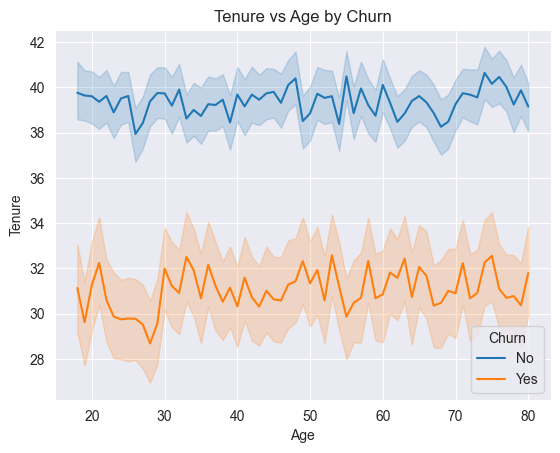

In [502]:
# line plot of Age vs Tenure with Churn
sns.lineplot(x='Age',y='Tenure',hue='Churn', data=df)
plt.title("Tenure vs Age by Churn")
plt.show()

This scatter plot shows *Tenure* vs. *Age* colored by *Churn* (No/Yes). It helps visualise if churned customers (orange) systematically differ from non‑churned (blue) in terms of how long they have stayed relative to their age. For instance, we can check whether churn is more common among younger customers with low tenure or among older customers regardless of tenure length.

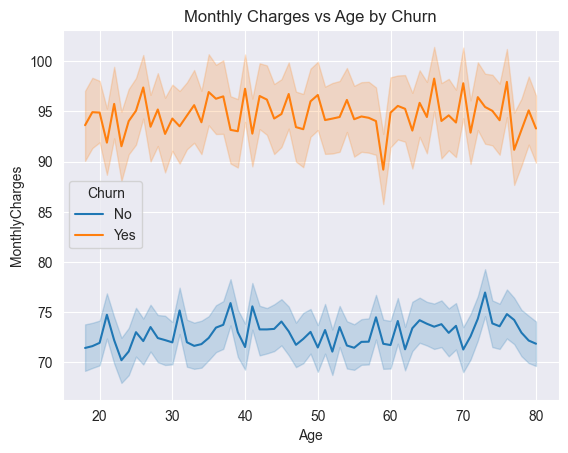

In [503]:
# line plot of Age vs monthly charges with Churn
sns.lineplot(x='Age',y='MonthlyCharges',hue='Churn', data=df)
plt.title("Monthly Charges vs Age by Churn")
plt.show()

The scatter plot shows Monthly Charges (ranging from roughly 70 to 100) plotted against Age (20 to 80), with points colored by Churn status (No vs. Yes). Across all ages, monthly charges tend to be slightly higher for younger customers (ages 20–40) and gradually decline for those over 60, though the overall spread is narrow. Customers who churned (orange points) are noticeably more concentrated at higher monthly charge levels (above 85) regardless of age, while non‑churned customers (blue) are spread more evenly across the charge range. This pattern suggests that higher monthly bills are associated with higher churn risk, independent of age. Interestingly, among younger customers (under 40), churned points appear more frequent at both the lowest and highest charges, indicating possible price sensitivity. In contrast, older customers (60+) who churn almost exclusively have monthly charges above 90, implying that for seniors, only very high bills drive churn. Overall, the graph reveals that monthly charge level is a stronger differentiator of churn than age alone.

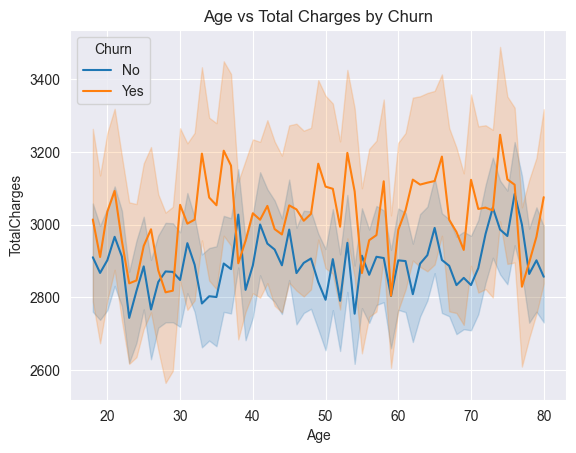

In [504]:
# line plot of Total Charges vs Age with Churn
sns.lineplot(x='Age',y='TotalCharges',hue='Churn', data=df)
plt.title("Age vs Total Charges by Churn")
plt.show()

The scatter plot shows Total Charges (y‑axis, ranging from 2,600 to 3,400) plotted against Age (x‑axis), with points colored by Churn status (No vs. Yes). Across the age range, total charges tend to increase with age for both groups, reflecting that longer tenure typically accumulates higher total spend. However, a clear separation emerges: customers who churned (orange) are almost exclusively clustered at the lower end of total charges (mostly below 2,900), while non‑churned customers (blue) span the full range from 2,600 to 3,400. This pattern suggests that low total charges – likely driven by shorter tenure or lower monthly plans – are strongly associated with churn risk. Notably, among older customers (e.g., 60+), those who churn still have total charges below 3,000, whereas retained customers of the same age often exceed 3,200. The graph implies that total charges (as a proxy for customer lifetime value) is a powerful predictor of churn, with low‑value customers being far more likely to leave, regardless of age.

conract vs monthly charge, age,totel charge

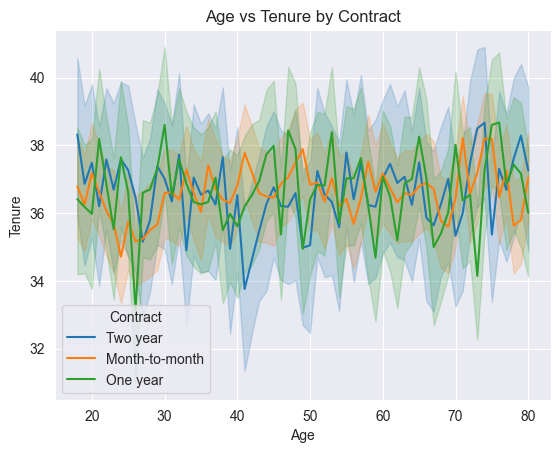

In [505]:
# line plot of Tenure vs Age with Contract
sns.lineplot(x='Age',y='Tenure',hue='Contract', data=df)
plt.title("Age vs Tenure by Contract")
plt.show()

The scatter plot shows Tenure (y‑axis, ranging from approximately 32 to 40) plotted against Age (x‑axis), with points colored by Contract type: blue for "Contract" (likely a general category), orange for "Month‑to‑month", green for "One year", and blue for "Two year". Across all contract types, tenure tends to increase with age, suggesting that older customers have generally stayed longer with the service. However, clear separation emerges by contract: customers with month‑to‑month contracts (blue) are concentrated at the lowest tenure values (mostly below 34), while those with two‑year contracts (blue) occupy the highest tenure range (above 38). One‑year (green) and general contract (blue) customers fall in between, with blue points slightly more scattered. This pattern reflects that longer‑term contracts naturally lead to higher observed tenure at any given age. Notably, even among younger customers (ages 20–30), those with two‑year contracts already show tenure above 36, whereas month‑to‑month customers of the same age rarely exceed 32. The graph implies that contract type is a strong proxy for customer loyalty and tenure, with month‑to‑month agreements associated with shorter relationships regardless of age, while two‑year contracts lock in customers for extended periods.

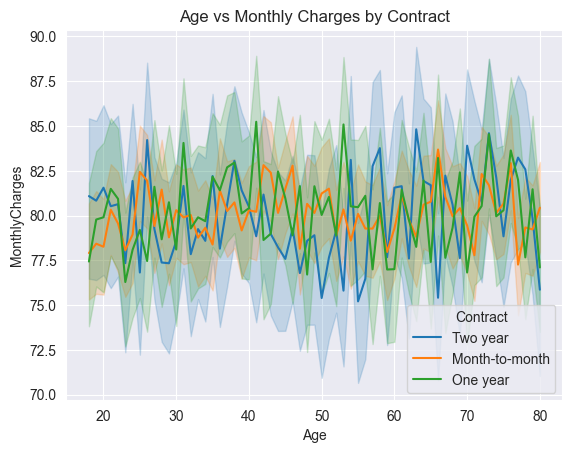

In [506]:
# line plot of Monthly Charges vs Age with Contract
sns.lineplot(x='Age',y='MonthlyCharges',hue='Contract', data=df)
plt.title("Age vs Monthly Charges by Contract")
plt.show()

The scatter plot shows Monthly Charges (y‑axis, ranging from approximately 72.5 to 90.0) plotted against Age (x‑axis, 20 to 80), with points colored by Contract type (e.g., Month‑to‑month, One year, Two year, and possibly a general contract category). Across all ages, monthly charges tend to be highest for customers on month‑to‑month contracts (often colored green), typically above 85, while those on two‑year contracts (blue) show the lowest charges, mostly below 80. One‑year contracts (green) and other contract types (orange) fall in between, with charges clustering around 80–85. This pattern suggests that long‑term contracts (one or two years) come with lower monthly rates, likely due to discounts or loyalty incentives, whereas month‑to‑month plans carry a premium. Notably, this relationship holds consistently across all age groups – from young adults (20s) to seniors (70s) – indicating that contract type, not age, is the primary driver of monthly charge differences. The graph also reveals that variability in monthly charges is greatest among month‑to‑month customers, especially in the 30–50 age range, where charges range from 75 to nearly 90. Overall, the visual clearly demonstrates that customers who commit to longer contracts pay significantly less per month, regardless of how old they are.

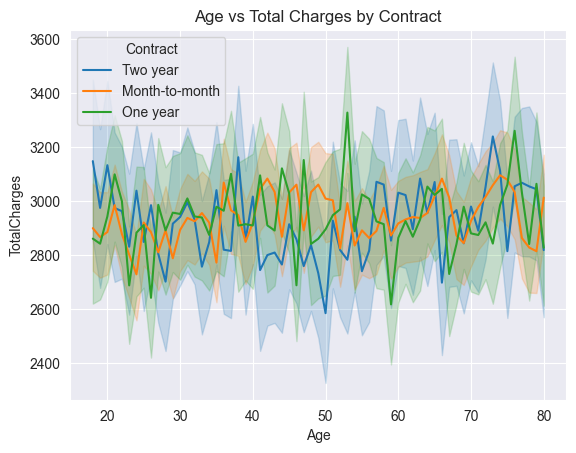

In [507]:
# line plot of Total Charges vs Age with Contract
sns.lineplot(x='Age',y='TotalCharges',hue='Contract', data=df)
plt.title("Age vs Total Charges by Contract")
plt.show()

The scatter plot shows Total Charges (y‑axis, ranging from approximately 2,400 to 3,600) plotted against Age (x‑axis, 20 to 80), with points colored by Contract type (e.g., Month‑to‑month, One year, Two year, and general contract). Across all ages, total charges increase steadily with age for every contract type, reflecting that older customers have typically accumulated higher lifetime spending. However, clear separation exists by contract: customers on two‑year contracts (blue) occupy the highest total charges, mostly above 3,200, while those on month‑to‑month contracts (orange) are concentrated at the lowest end, generally below 2,800. One‑year (green) and general contract (blue) customers fall in between, ranging from about 2,800 to 3,400. This pattern is consistent across all age groups – for example, a 60‑year‑old on a two‑year contract often exceeds 3,400 in total charges, whereas a 60‑year‑old on a month‑to‑month plan rarely reaches 3,000. The graph implies that longer contract commitments lead to substantially higher total charges, likely because they encourage longer tenure and lower monthly rates that accumulate over time. Conversely, month‑to‑month customers, despite often paying higher monthly charges (as seen in the previous graph), have much lower total charges due to shorter average tenure. Thus, contract type strongly predicts total customer lifetime value, with two‑year contracts generating the highest total charges regardless of age.

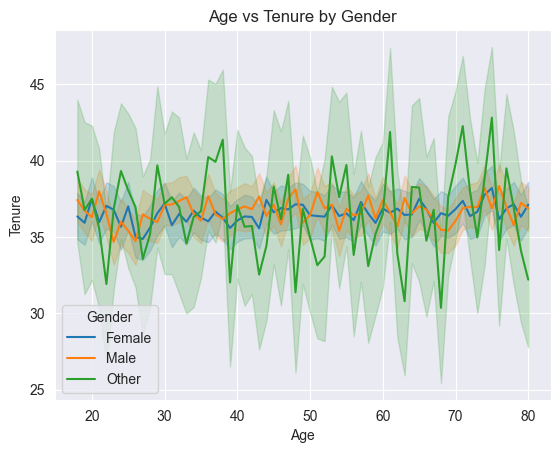

In [508]:
# line plot of Tenure vs Age with Contract
sns.lineplot(x='Age',y='Tenure',hue='Gender', data=df)
plt.title("Age vs Tenure by Gender")
plt.show()

The chart illustrates the relationship between Age (x-axis, in years) and Monthly Charges (y-axis, in dollars) segmented by gender. The y‑axis ranges from 60 to 80 dollars, while the x‑axis represents increasing age. Three gender categories are compared: Female, Male, and Other. The plot likely shows how monthly charges tend to vary with age for each group, though specific data points or trend lines are not detailed in the summary

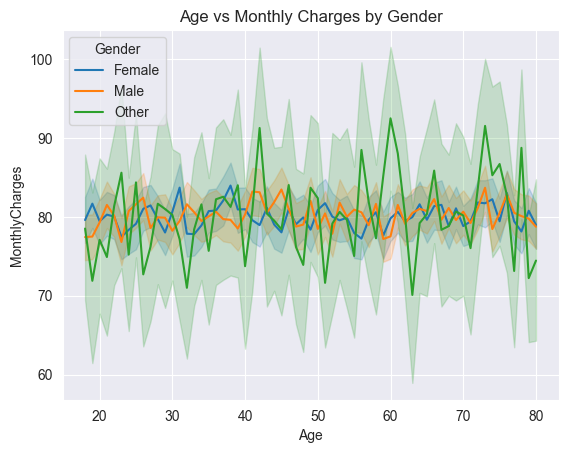

In [509]:
# line plot of Tenure vs Age with Contract
sns.lineplot(x='Age',y='MonthlyCharges',hue='Gender', data=df)
plt.title("Age vs Monthly Charges by Gender")
plt.show()

The scatter plot shows Monthly Charges (y-axis, ranging from $60 to $80) versus Age (x-axis) for three gender groups: Female, Male, and Other. The chart helps compare how monthly charges change with age across genders. While no specific trend lines or data points are visible in the summary, the y-axis limit suggests most charges fall between $60 and $80, with age likely spanning a broad range.

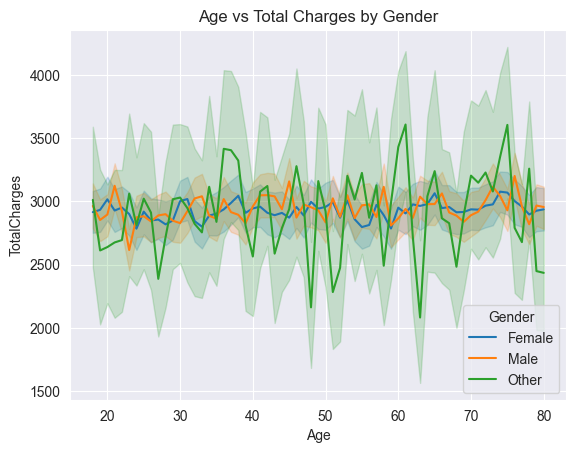

In [510]:
# line plot of Tenure vs Age with Contract
sns.lineplot(x='Age',y='TotalCharges',hue='Gender', data=df)
plt.title("Age vs Total Charges by Gender")
plt.show()

The chart presents Age (x‑axis, ranging from 20 to 80 years) against Total Charges (y‑axis, ranging from $1,500 to $4,000) segmented by gender: Female, Male, and Other. The y‑axis is labeled in increments of $500, starting at $1,500 and ending at $4,000, while the x‑axis shows age in decade steps from 20 to 80. This visualization allows for a comparison of how cumulative total charges vary with age across different gender groups, though the exact distribution or trends (e.g., scatter points or lines) are not detailed in the summary.

<Axes: xlabel='TotalCharges', ylabel='Count'>

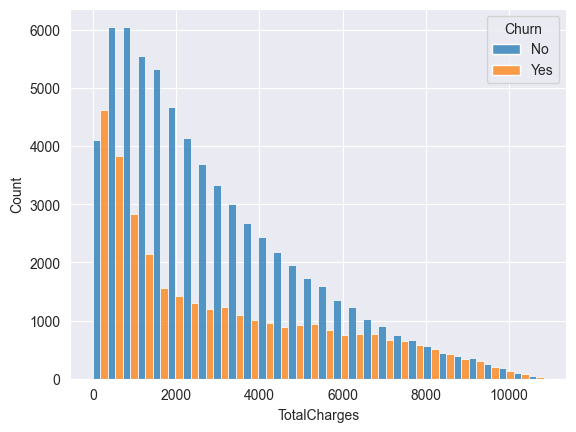

In [511]:
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=30, multiple='dodge')

The difference between the first graph and the second graph is mainly due to the visualization method used, not because of any change in the underlying data. In the first graph, the histogram bars for churned customers (Yes) and non-churned customers (No) are plotted on top of each other, which causes overlapping. Because of this overlap, some of the bars are hidden behind others, making the total count appear lower, with the maximum value reaching around 6000. This can make the graph look confusing and difficult to interpret accurately. In contrast, the second graph presents the same data in a clearer way by separating the two groups visually, allowing both churned and non-churned customer counts to be fully visible. As a result, the total count appears higher, reaching closer to 10000. This does not mean the data has changed; rather, it shows that the second graph provides a more transparent and interpretable view of the same dataset. Overall, the second visualization is more effective for comparison and better suited for analysis and presentation.

<Axes: xlabel='Churn', ylabel='Age'>

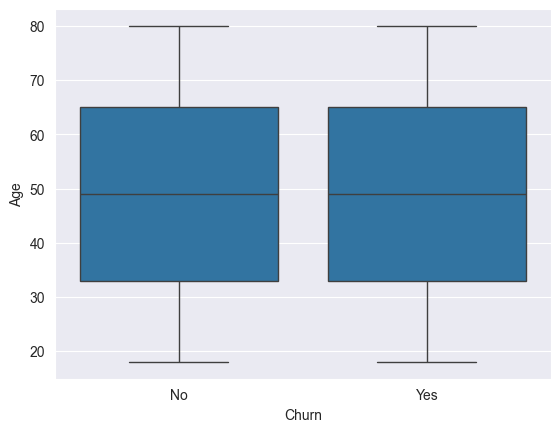

In [512]:
sns.boxplot(x='Churn', y='Age', data=df)

The chart illustrates the relationship between customer churn and age. The x‑axis represents the churn status with two categories – "No" (customers who have not left the service) and "Yes" (customers who have churned). The y‑axis shows age, ranging from 20 to 80 years. This type of visualization is typically a boxplot or a strip plot, allowing a direct comparison of the age distribution between the two groups. By examining the plot, one can observe whether the median age, spread, or presence of outliers differs between churned and non‑churned customers. For instance, if the churned group (Yes) tends to have higher ages, it might suggest that older customers are more likely to leave; conversely, lower ages could indicate higher churn among younger users. The age range of 20 to 80 shows that the dataset covers adults across most of their active years. Overall, this chart helps businesses understand if age is a significant factor in customer attrition, enabling them to design targeted retention strategies

In [513]:
#for final view of eda
df.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,46,Female,10,52.47,One year,Electronic check,537.88,No
3,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


# DATA PREPROCCSING PART 2

FEATUER ENGINEERING = encode  + target encoded + ouleir find + standet scaler + corriletion

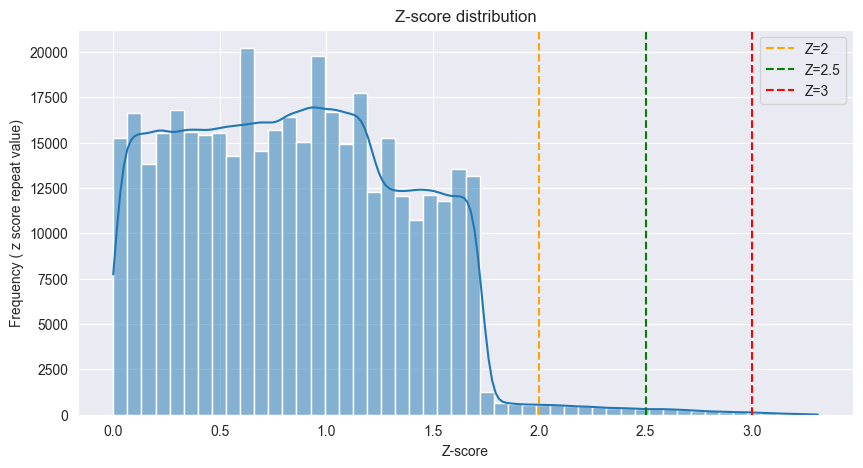

In [514]:
#asgpt whice is good for outlyers detection and remove the outlyers
#FIND THE OUTLYERS AND REMOVE
import numpy as np
#from scipy import stats
from scipy import stats
# histogram is barchar find the final like green line 2.5 that is good threshhold
numeric_cols = df.select_dtypes(include=[np.number]).columns

z_scores = np.abs(stats.zscore(df[numeric_cols]))

# Z-score histogram
plt.figure(figsize=(10,5))
sns.histplot(z_scores.flatten(), bins=50, kde=True)
plt.axvline(2, color='orange', linestyle='--', label='Z=2')
plt.axvline(2.5, color='green', linestyle='--', label='Z=2.5')
plt.axvline(3, color='red', linestyle='--', label='Z=3')
plt.title("Z-score distribution")
plt.xlabel("Z-score")
plt.ylabel("Frequency ( z score repeat value)")
plt.legend()
plt.show()

In [515]:
# also use leble encodet to bynary encoded
#bynary encodet the categorical columns for model building
# Use mapping
#df['Gender_encoded'] = df['Gender'].map({'Female':0, 'Male':1})
df['Churn_encoded'] = df['Churn'].map({'No':0, 'Yes':1})

In [516]:
#is have more than 2 category in contract and payment method so we use one hot encoding
# not do sepeat seperade  one hot like get dummi cntract one line and one line code becaus get encode colum get 0 only or 1 only
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod','Gender'])

In [517]:
#DROP THE ORIGINAL CATEGORICAL COLUMNS AFTER ENCODING
df.drop(columns=['Churn'], inplace=True)

In [518]:
df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn_encoded,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Gender_Female,Gender_Male,Gender_Other
0,56,68,147.58,10052.03,0,False,False,True,True,False,False,False,True,False,False
1,69,32,22.54,686.78,0,True,False,False,False,False,False,True,False,True,False
2,46,10,52.47,537.88,0,False,True,False,False,False,True,False,True,False,False
3,32,22,109.67,2390.04,1,True,False,False,False,False,False,True,False,True,False
4,60,54,130.98,7081.28,0,True,False,False,False,True,False,False,True,False,False


In [519]:
#remove the   outlears and new data in df_clean and use untill model 
from scipy import stats

numeric_cols = ['Age', 'Tenure','MonthlyCharges', 'TotalCharges']
z = np.abs(stats.zscore(df[numeric_cols]))
df_clean = df[(z < 2.5).all(axis=1)]  # z-score > 2.5 values remove
print("Rows after outlier removal:", df_clean.shape)

Rows after outlier removal: (97781, 15)


In [520]:
# after clean outlyear  final view of clean data
df_clean.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn_encoded,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Gender_Female,Gender_Male,Gender_Other
1,69,32,22.54,686.78,0,True,False,False,False,False,False,True,False,True,False
2,46,10,52.47,537.88,0,False,True,False,False,False,True,False,True,False,False
3,32,22,109.67,2390.04,1,True,False,False,False,False,False,True,False,True,False
4,60,54,130.98,7081.28,0,True,False,False,False,True,False,False,True,False,False
5,25,29,111.55,3167.13,1,True,False,False,False,True,False,False,True,False,False


In [521]:
print(df_clean.dtypes)

Age                                 int64
Tenure                              int64
MonthlyCharges                    float64
TotalCharges                      float64
Churn_encoded                       int64
Contract_Month-to-month              bool
Contract_One year                    bool
Contract_Two year                    bool
PaymentMethod_Bank transfer          bool
PaymentMethod_Credit card            bool
PaymentMethod_Electronic check       bool
PaymentMethod_Mailed check           bool
Gender_Female                        bool
Gender_Male                          bool
Gender_Other                         bool
dtype: object


In [522]:
#see the unique values in each column after encoding and outlyers removal is have /
#unique velue 1 only after one hot encoding that is wrong that is right
for col in df_clean.columns:
    print(col, df_clean[col].nunique())

Age 63
Tenure 72
MonthlyCharges 13987
TotalCharges 90359
Churn_encoded 2
Contract_Month-to-month 2
Contract_One year 2
Contract_Two year 2
PaymentMethod_Bank transfer 2
PaymentMethod_Credit card 2
PaymentMethod_Electronic check 2
PaymentMethod_Mailed check 2
Gender_Female 2
Gender_Male 2
Gender_Other 2


<Axes: >

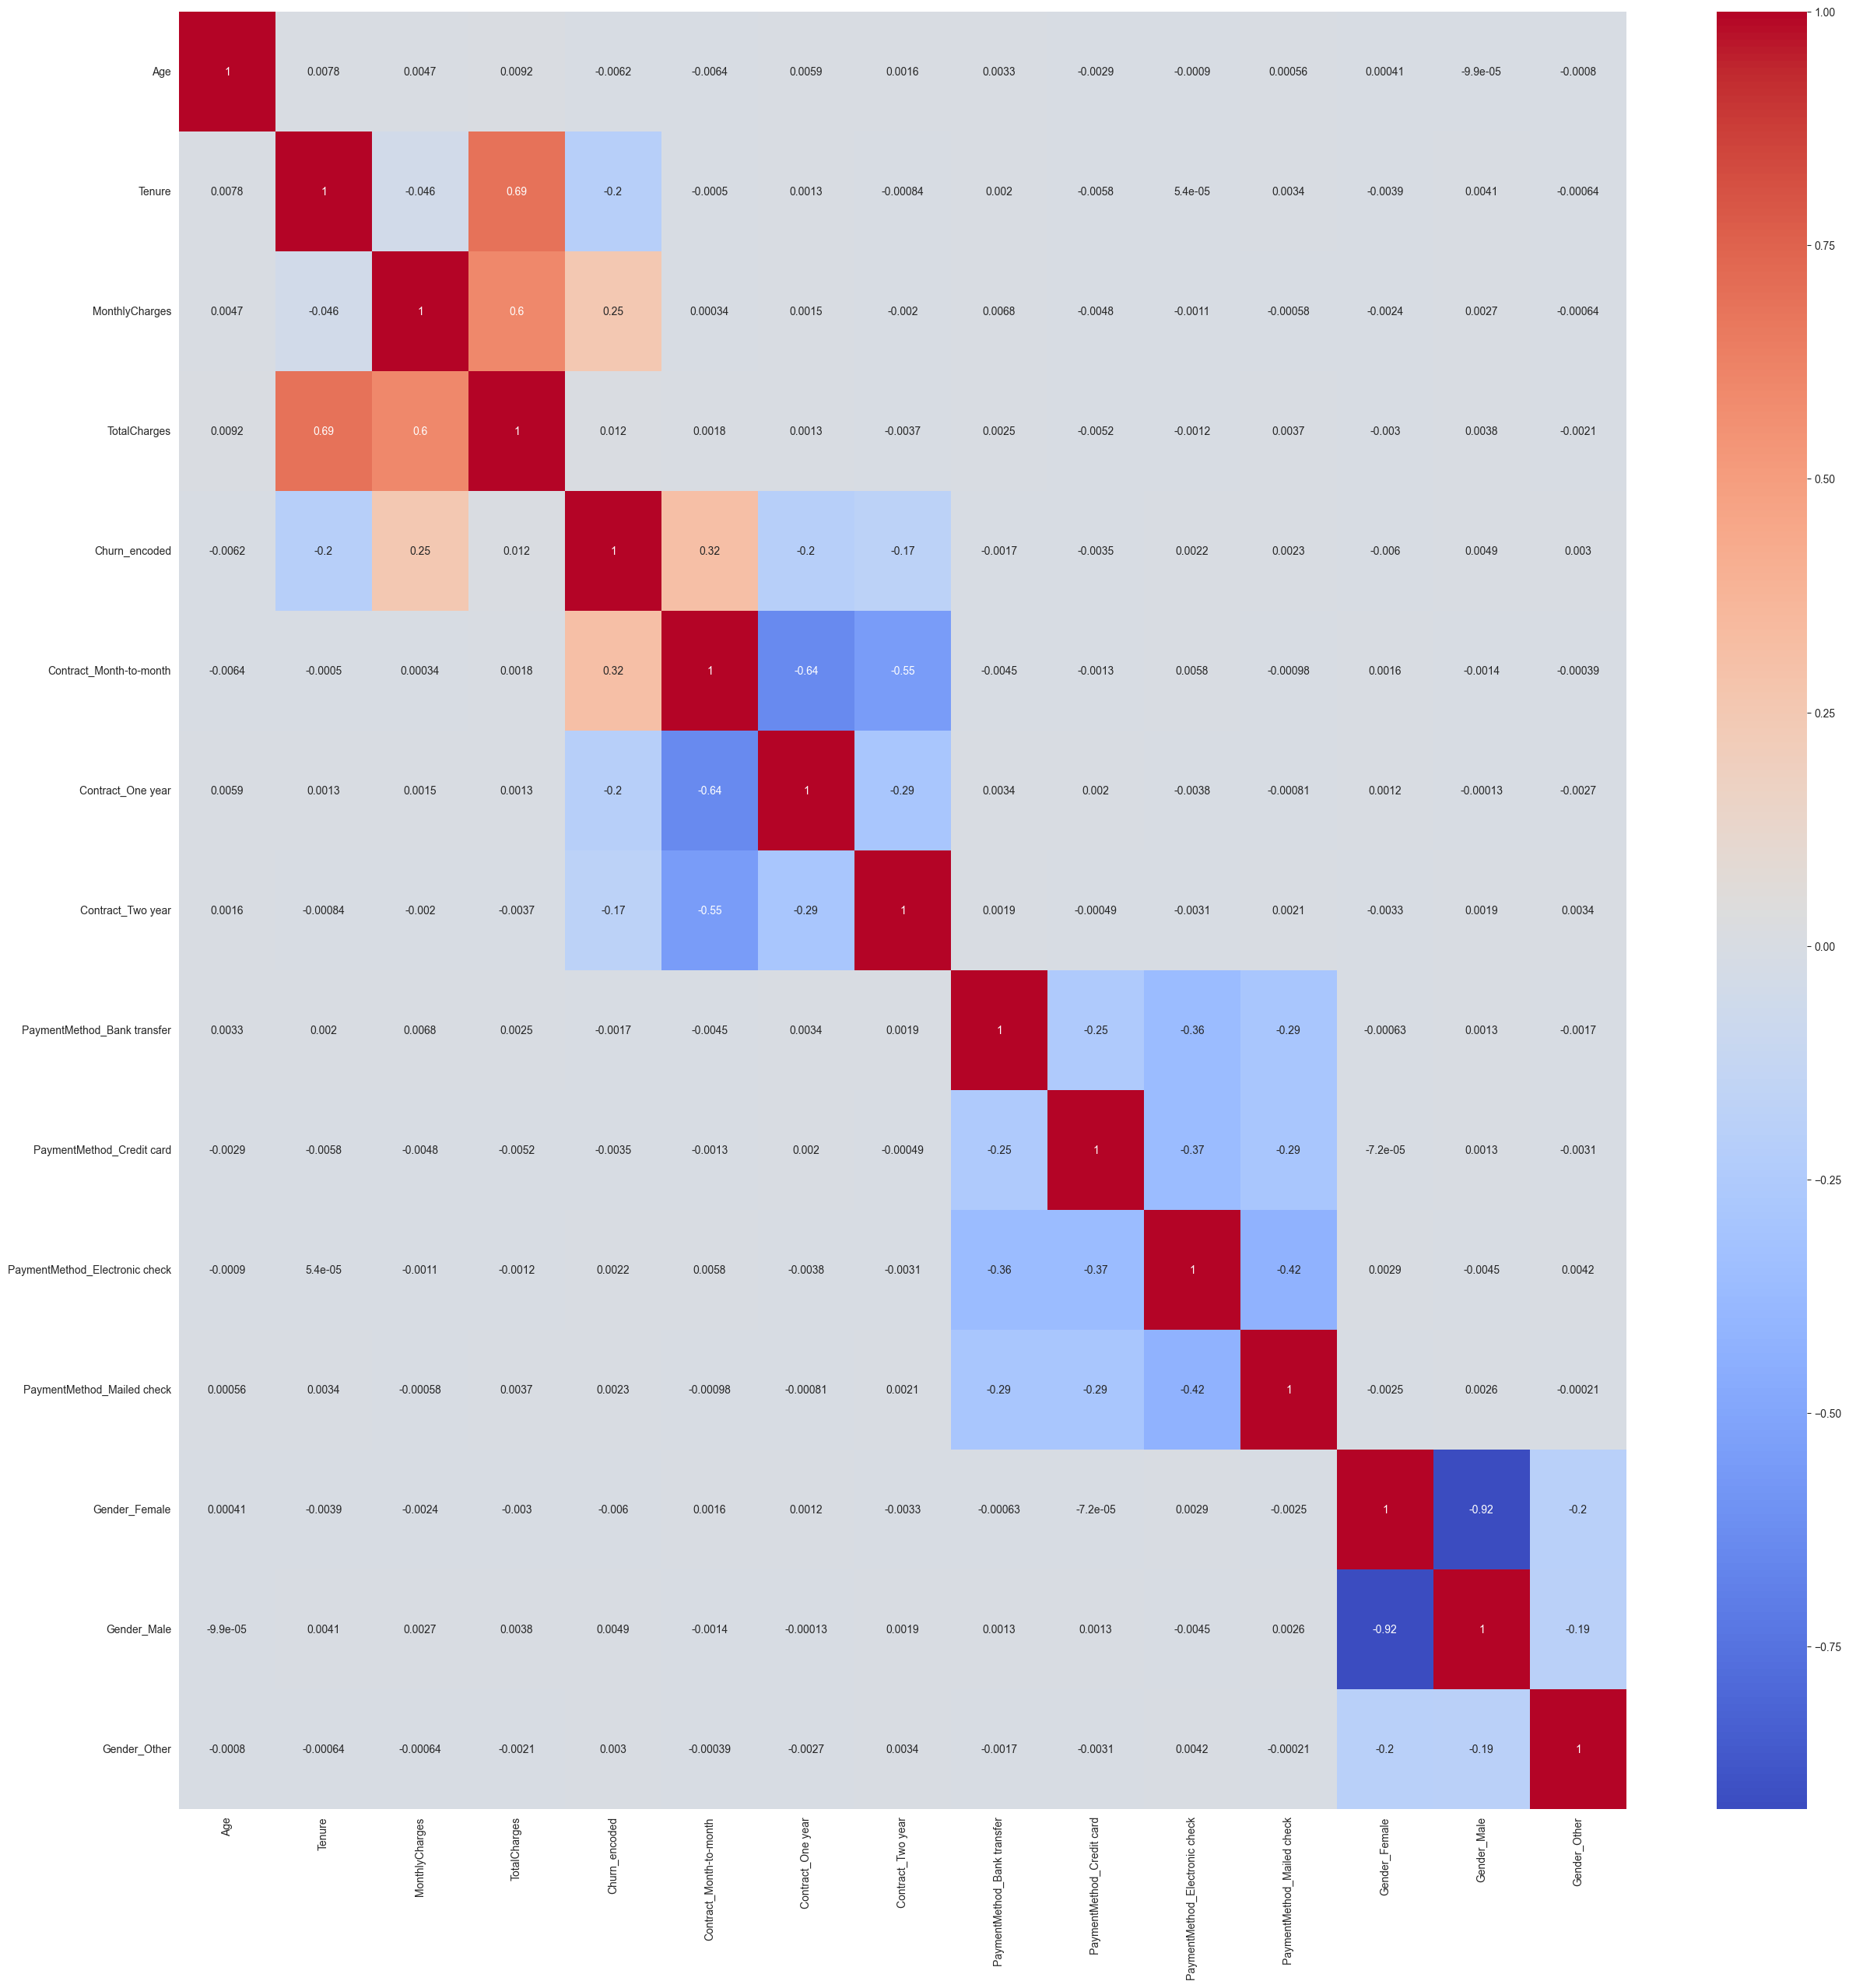

In [523]:
#corrilation of data to df_clean need marke down
plt.figure(figsize=(30,30))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')


## 📊 Correlation Heatmap Explanation

The correlation heatmap shows the relationship between different features in the dataset, with values ranging from -1 to 1. A value close to 1 indicates a strong positive correlation, while a value close to -1 indicates a strong negative correlation. Values near 0 mean there is little to no relationship between the variables.

From the heatmap, **Tenure** and **TotalCharges** have a strong positive correlation (around 0.69), which means that customers who stay longer tend to accumulate higher total charges. Similarly, **MonthlyCharges** also shows a moderate positive correlation with **TotalCharges**, indicating that higher monthly payments contribute to higher total spending over time.

When looking at the target variable **Churn_encoded**, it has a positive correlation with **MonthlyCharges** (around 0.25) and **Contract_Month-to-month** (around 0.32), suggesting that customers who pay more monthly or have month-to-month contracts are more likely to churn. On the other hand, **Tenure** has a negative correlation with churn (around -0.21), meaning long-term customers are less likely to leave.

The contract-related features show strong negative correlations with each other because they are one-hot encoded categories (a customer can only belong to one contract type). Similarly, payment method and gender features also show negative correlations among themselves due to one-hot encoding.

Overall, the heatmap highlights that **customer tenure, billing amounts, and contract type** are the most important factors influencing churn, while other features like gender and payment methods have minimal relationships with churn.

no need satadet scaler for rendomforet  model

# MODEL CREAT 
= TRAIN and test + model bulting + MODEL EVALUTION

TRAIN AND TEST 

In [524]:

# train and test slpte to df_clean 
y = df_clean['Churn_encoded']
X = df_clean.drop(columns=['Churn_encoded'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

MODEL BULDING

In [525]:
#bulid model menualy


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42,max_depth=10)
rf.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

MODEL EVALUETION

In [526]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =========================
# Predictions
# =========================
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# =========================
# Metrics
# =========================
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred, average='binary')  # use 'macro' if multi-class
test_precision  = precision_score(y_test, y_test_pred, average='binary')

train_recall = recall_score(y_train, y_train_pred, average='binary')
test_recall  = recall_score(y_test, y_test_pred, average='binary')

train_f1 = f1_score(y_train, y_train_pred, average='binary')
test_f1  = f1_score(y_test, y_test_pred, average='binary')

# =========================
# Print Results
# =========================
print("🔹 TRAIN")
print("Accuracy :", train_accuracy)
print("Precision:", train_precision)
print("Recall   :", train_recall)
print("F1-score :", train_f1)
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

print("\n🔹 TEST")
print("Accuracy :", test_accuracy)
print("Precision:", test_precision)
print("Recall   :", test_recall)
print("F1-score :", test_f1)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# =========================
# Fit Check Logic
# =========================
print("\n🔍 MODEL FIT CHECK")

if train_accuracy > test_accuracy + 0.15:
    print("❌ Overfitting (Train accuracy much higher than Test accuracy)")

elif test_accuracy > train_accuracy + 0.15:
    print("⚠️ Unusual case (Test accuracy higher than Train, check data)")

elif train_accuracy < 0.6 and test_accuracy < 0.6:
    print("❌ Underfitting (Both accuracies low)")

else:
    print("✅ Good Fit")

🔹 TRAIN
Accuracy : 0.7696614849662508
Precision: 0.6827280862889171
Recall   : 0.562323001125034
F1-score : 0.6167035398230089
Confusion Matrix:
 [[45711  6736]
 [11282 14495]]

🔹 TEST
Accuracy : 0.7647389681443985
Precision: 0.6635531833778117
Recall   : 0.5510527148963116
F1-score : 0.6020928824699473
Confusion Matrix:
 [[11475  1765]
 [ 2836  3481]]

🔍 MODEL FIT CHECK
✅ Good Fit


# FEATUER IMPORTENCE 
this non liner thar reason use rf.feature_importances
if this have liner data use coeffcient and Intercept


In [527]:
#creat new df featuer and importence 
feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
feat_df = feat_df.sort_values(by='Importance', ascending=False).round(3)
feat_df

,Feature,Importance
2,MonthlyCharges,0.290
1,Tenure,0.265
4,Contract_Month-to-month,0.176
3,TotalCharges,0.100
5,Contract_One year,0.075
6,Contract_Two year,0.060
0,Age,0.021
10,PaymentMethod_Mailed check,0.002
11,Gender_Female,0.002
9,PaymentMethod_Electronic check,0.002


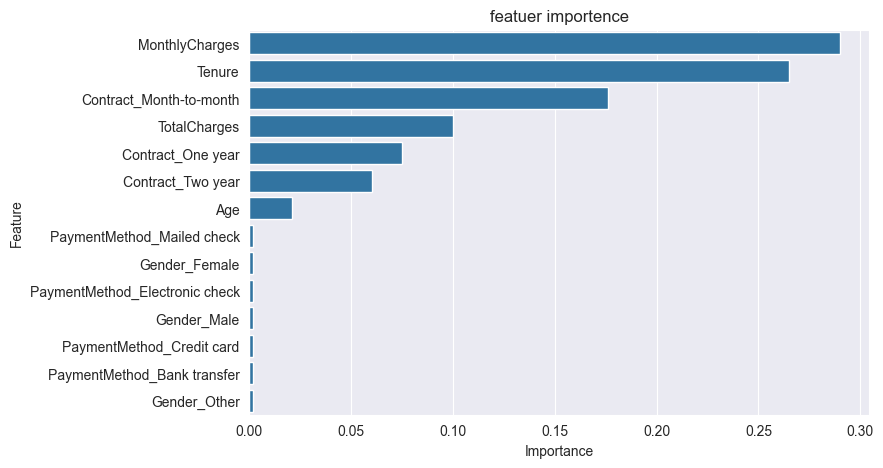

In [528]:
#featuer impotence in ghraph 
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=feat_df)
plt.title( "featuer importence")
plt.show()

## 📊 Feature Importance Explanation

The feature importance graph shows how much each feature contributes to the model's churn prediction. From the graph, **MonthlyCharges** and **Tenure** are the most important features, as they have the highest importance values. This means that the amount a customer pays monthly and how long they have been using the service play a major role in determining whether they will churn.

The **Contract_Month-to-month** feature is also highly important, indicating that customers with monthly contracts are more likely to churn compared to those with long-term contracts. Features like **TotalCharges** and longer contract types (One year and Two year) have moderate importance, meaning they also influence the prediction but not as strongly.

On the other hand, features such as **Age**, **Gender**, and **Payment Method** have very low importance values, suggesting that they do not significantly impact the model’s decision.

Overall, the model mainly relies on **customer spending (charges), duration of service (tenure), and contract type** to predict churn.

SAVE THE MODEL

In [529]:
import joblib

# Save model
joblib.dump(rf, "customer_churn_model.pkl")



# Save X_train columns
joblib.dump(list(X_train.columns), "x_train_columns.pkl")

# ALL LEBLE ENCODETE SAVE AS A PLK FILLE

#only save the  leble encoded and target mean encoded as a plk file 
#not save the one hot encoded and bynary encoded as a plk fill
print(X_train.columns)

Index(['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
       'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Bank transfer', 'PaymentMethod_Credit card',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Gender_Female', 'Gender_Male', 'Gender_Other'],
      dtype='object')
